In [17]:
import os.path, time
import onnxruntime as ort
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as colors

from utils.dataset import load_dataset_v2
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from matplotlib.ticker import MultipleLocator, LogLocator
from tqdm.notebook import tqdm

In [18]:
seq_len = 10
model = ort.InferenceSession(f'models/model_{seq_len}.onnx')

In [19]:
feature_name_list = ['pressure_1(bar)', 'main_pressure(bar)']
target_name = 'outlet_flowrate(lpm)'

file_name_list = os.listdir(os.path.join('data', 'ver_2'))
file_path_list = []

for file_name in file_name_list:
    file_path_list.append(os.path.join('data', 'ver_2', file_name))

dataset = load_dataset_v2(file_path_list)
dataset = dataset[::10]
dataset.reset_index(drop=True, inplace=True)

loading dataset...:   0%|          | 0/84 [00:00<?, ?it/s]

In [20]:
dataset = dataset[::5]
dataset.reset_index(drop=True, inplace=True)

dataset.shape

(46305, 18)

In [21]:
new_dataset = dataset.copy()
new_dataset = new_dataset[new_dataset[target_name] > 1]
new_dataset.reset_index(drop=True, inplace=True)

new_dataset = new_dataset[feature_name_list+[target_name]].to_numpy()
new_dataset.shape

(39305, 3)

In [22]:
n_of_features = len(feature_name_list)

input_buf = np.zeros(shape=(1, seq_len, n_of_features), dtype=np.float32)

est_flow_arr = []
gt_flow_arr = []

for sig_set in tqdm(new_dataset):
    input_buf = np.roll(a=input_buf, shift=-1, axis=1)
    input_buf[0, -1, :] = sig_set[0:2]

    est_flow = np.squeeze(model.run(output_names=None, input_feed={'input': input_buf})).item()
    est_flow_arr.append(est_flow)
    gt_flow_arr.append(sig_set[2])

est_flow_arr = np.array(est_flow_arr)
gt_flow_arr = np.array(gt_flow_arr)

  0%|          | 0/39305 [00:00<?, ?it/s]

In [23]:
print(r2_score(gt_flow_arr, est_flow_arr))
print(mean_absolute_error(gt_flow_arr, est_flow_arr))
print(mean_absolute_percentage_error(gt_flow_arr, est_flow_arr))

0.9926194668271091
27.674519791699538
0.06460907135040876


<Axes: >

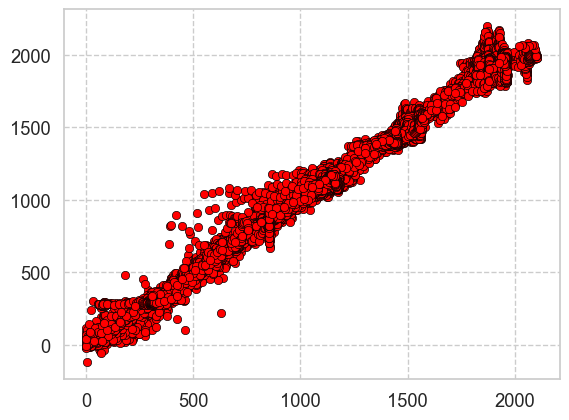

In [24]:
sns.set_theme(font_scale=1.2)
sns.set_style('whitegrid', {'grid.linestyle': '--'})

sns.scatterplot(x=gt_flow_arr, y=est_flow_arr, color='red', edgecolor='black')